In [53]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

np.set_printoptions(precision=2, suppress=True)

In [60]:
temp = np.array([29.0, 54.9, 62.1, 22.0, 30.4, 85.0, 24.9, 29.1, 86.4, 63.5, 45.8, 55.8, 66.4, 39.3, 29.7, 75.2, 66.9, 55.9, 77.2, 58.4, 88.7, 34.3, 58.8, 53.9, 44.7, 61.4, 36.5, 76.2, 80.7, 29.0, 52.7, 39.4, 25.8, 82.7, 50.1])
conc = np.array([1.61, 5.55, 2.02, 7.26, 2.13, 0.75, 2.01, 3.09, 4.02, 7.30, 5.73, 3.04, 0.63, 1.70, 7.97, 3.95, 5.68, 0.91, 0.76, 6.84, 4.91, 2.82, 2.88, 1.17, 1.80, 0.68, 6.79, 4.00, 1.45, 6.04, 1.97, 0.96, 4.99, 7.22, 0.70])
y_train = np.array([10.62, 35.77, 22.94, 15.29, 14.30, 20.29, 13.50, 14.14, 41.99, 43.79, 30.17, 24.37, 15.95, 12.96, 21.99, 38.21, 38.64, 13.86, 15.82, 39.72, 48.30, 19.65, 23.66, 14.65, 17.25, 15.74, 26.76, 36.36, 23.45, 20.84, 19.17, 10.13, 18.43, 53.62, 11.69])

y_train.shape

(35,)

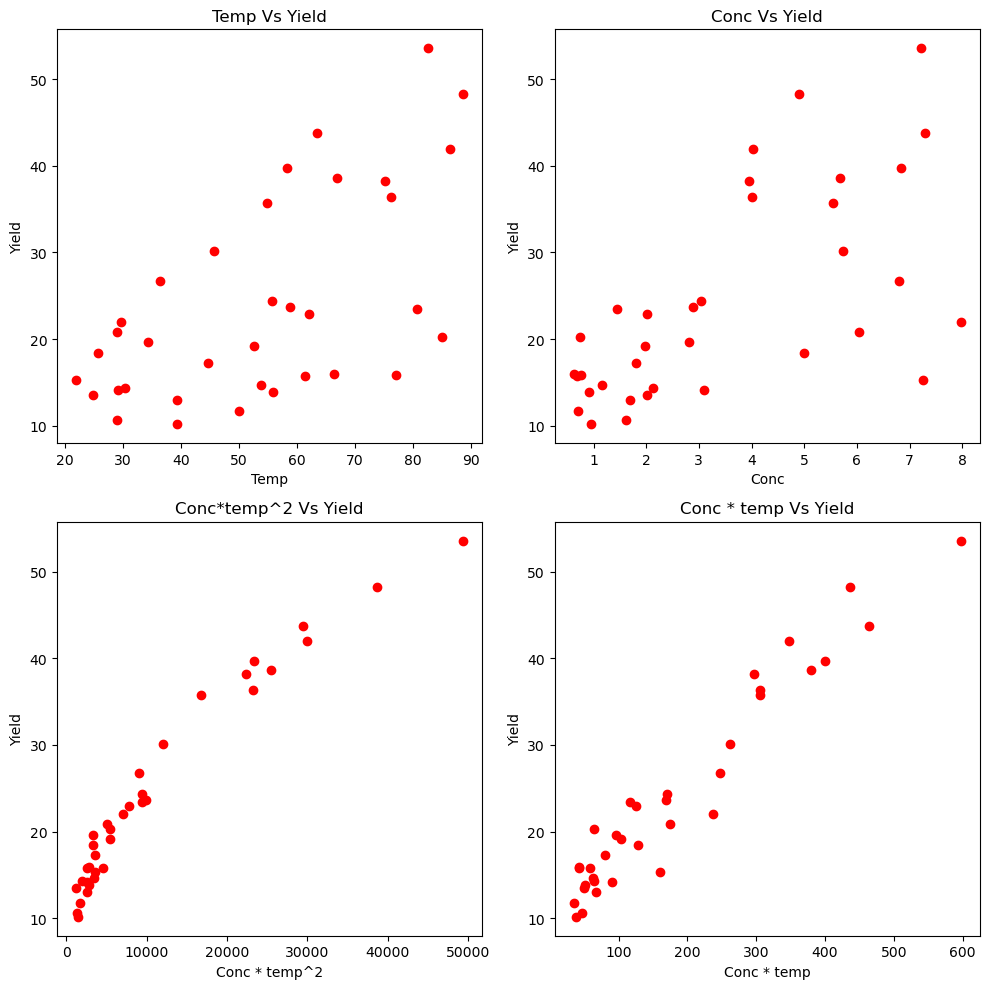

In [77]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

ax[0, 0].scatter(temp, y_train, marker="o", color="r")
ax[0, 0].set_xlabel("Temp")
ax[0, 0].set_ylabel("Yield")
ax[0, 0].set_title("Temp Vs Yield")

ax[0, 1].scatter(conc, y_train, marker="o", color="r")
ax[0, 1].set_xlabel("Conc")
ax[0, 1].set_ylabel("Yield")
ax[0, 1].set_title("Conc Vs Yield")

ax[1, 0].scatter((conc)*(temp**2), y_train, marker="o", color="r")
ax[1, 0].set_xlabel("Conc * temp^2")
ax[1, 0].set_ylabel("Yield")
ax[1, 0].set_title("Conc*temp^2 Vs Yield")


ax[1, 1].scatter(conc*temp, y_train, marker="o", color="r")
ax[1, 1].set_xlabel("Conc * temp")
ax[1, 1].set_ylabel("Yield")
ax[1, 1].set_title("Conc * temp Vs Yield")

plt.tight_layout()
plt.show()

In [162]:
x_train = np.array([temp, conc, (temp)*conc])
x_train = x_train.T

x_train.shape

(35, 3)

In [153]:
def predict(x, w, b):
    prediction = x @ w + b
    return prediction

In [154]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    
    cost = ((x @ w + b) - y)**2
    cost = cost.sum()
    cost /= 2 *m

    return cost

In [155]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]

    err = (x @ w + b) - y
    dj_dw = err @ x
    dj_db = err.sum()

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [156]:
def gradient_descent(x, y, w_init, b_init, threshold, alpha, iterations):
    w = w_init
    b = b_init

    cost = []

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        cost.append(compute_cost(x, y, w, b))

        if i % math.ceil(iterations / 10) == 0:
            print(f"Iteration: {i}, cost: {cost[-1]}")
        
        if all(abs(dj_dw) < threshold) and abs(dj_db) < threshold:
            print(f"Final: {i}th iteration, cost: {cost[-1]}")
            break

    return w, b, cost

In [157]:
def z_scale(x):
    mean = x.mean(axis=0)
    sigma = x.std(axis=0)

    x_scaled = (x - mean) / sigma

    return x_scaled, mean, sigma

In [163]:
x_scaled, mean, sigma = z_scale(x_train)

np.ptp(x_scaled, axis=0)

array([3.36, 3.14, 3.88])

In [170]:
w = np.zeros(3)
b = 0
alpha = np.array([0.03])
threshold = 0.01
iterations = 10000


for i in range(len(alpha)):
    print(f"Alpha: {alpha[i]}")
    final_w, final_b, cost_list = gradient_descent(x_scaled, y_train, w, b, threshold, alpha[i], iterations)
    

Alpha: 0.03
Iteration: 0, cost: 334.52867815828023
Iteration: 1000, cost: 1.6411038121176809
Iteration: 2000, cost: 1.5750126370201425
Final: 2200th iteration, cost: 1.5733006913901841


In [171]:
final_prediction = predict(x_scaled, final_w, final_b)

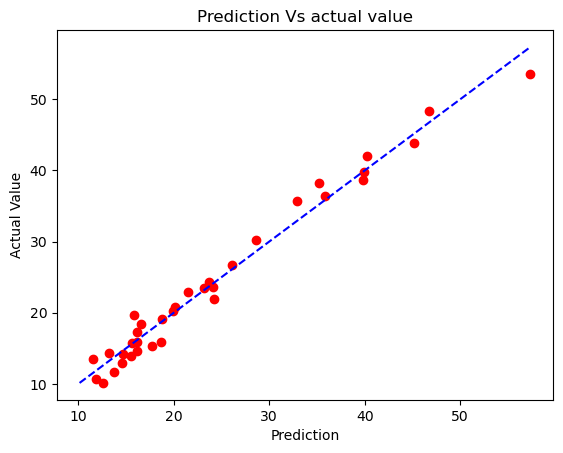

In [190]:
plt.scatter(final_prediction, y_train, marker='o', color='r')

lo = min(min(final_prediction), min(y_train))
hi = max(max(final_prediction), max(y_train))

plt.title("Prediction Vs actual value")
plt.xlabel("Prediction")
plt.ylabel("Actual Value")
plt.plot([lo,hi], [lo, hi], color='b', linestyle="--")
plt.show()

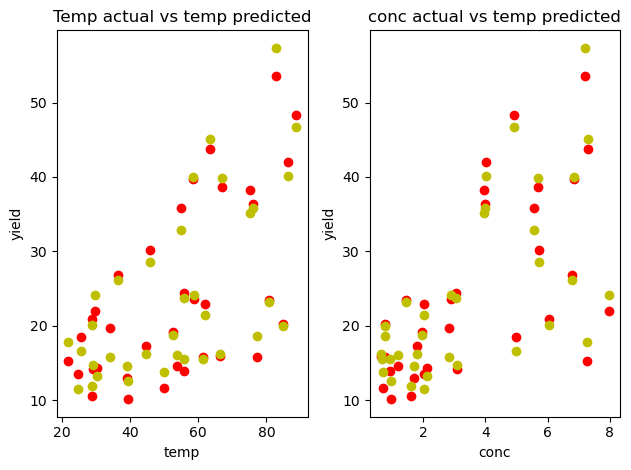

In [186]:
fig, ax = plt.subplots(1, 2)

ax[0].scatter(x_train[:, 0], y_train, color="r")
ax[0].scatter(x_train[:, 0], final_prediction, color="y")
ax[0].set_title("Temp actual vs temp predicted")
ax[0].set_xlabel("temp")
ax[0].set_ylabel("yield")

ax[1].scatter(x_train[:, 1], y_train, color="r")
ax[1].scatter(x_train[:, 1], final_prediction, color="y")
ax[1].set_title("conc actual vs temp predicted")
ax[1].set_xlabel("conc")
ax[1].set_ylabel("yield")

plt.tight_layout()
plt.show()

In [189]:
# final prediction
x = np.array([60, 4.5, 60*4.5])
scale_x = (x - mean) / sigma
predict_ans = predict(scale_x, final_w, final_b)
print(f"final yeild for 60 degree celcius and conc of 4.5 % is: {predict_ans:.2f}")

final yeild for 60 degree celcius and conc of 4.5 % is: 31.22
